# **Diplomado IA: Inteligencia Artificial II - Parte 2**. <br> Práctico 1: Modelos con memoria externa
---
---

**Profesor:** Andres Espinosa (aespinosa1@uc.cl)

# Introducción

En este *notebook* implementaremos el modelo del trabajo [Key-Value Memory Networks for Directly Reading Documents](https://arxiv.org/abs/1606.03126) aplicado en la tarea de Question Answering (QA). Específicamente, utilizaremos el set de datos [WikiMovies](https://research.fb.com/downloads/babi/), que contiene preguntas y respuestas sobre películas.

El contenido de este *notebook* está basado principalmente en [esta implementación](https://github.com/berlino/MemNN) en PyTorch, y también tomó algunos elementos de la [implementación original](https://github.com/facebook/MemNN/tree/master/KVmemnn) (escrito en Torch/Lua). La implementación final con todos los cambios/mejoras necesarias la pueden encontrar [acá](https://github.com/andresespinosapc/MemNN), pero en este *notebook* la simplificaremos más todavía.

Como ya vimos en la clase, el modelo que vamos a implementar tiene una base de conocimiento estructurada como keys y values, y tiene un controlador que se encarga de aprender cómo utilizar esta base de conocimiento para responder a las preguntas, utilizando el key para encontrar las entradas que necesita y los values como valores que va guardando en su representación interna para responder.

# Carga de datos

## Instalar librerías

In [6]:
!pip install torchfile
!pip install flashtext

  Preparing metadata (setup.py) ... done
  Created wheel for torchfile: filename=torchfile-0.1.0-py3-none-any.whl size=5693 sha256=3d86ac80e640e632dd406e643e249ec484d2dc4959c6ba71c9533ac0364c8dd5
  Stored in directory: /root/.cache/pip/wheels/7c/6f/28/cc50c3bad0a19722871d23fe2264de477c76e8216f914c7031
Successfully built torchfile
  Preparing metadata (setup.py) ... done
  Created wheel for flashtext: filename=flashtext-2.7-py2.py3-none-any.whl size=9300 sha256=30564f76a55e6b50f0794519ae127272428539ffe5a8d55d4d1defc6dd45f022
  Stored in directory: /root/.cache/pip/wheels/8c/24/da/4d994d7a27cfc73a4e513a669fbeec4a71f871fe245a81977f
Successfully built flashtext


## Importar librerías

In [7]:
import os
from tqdm import tqdm
import torchfile

## Descargar datos

Primero descargamos los datos. Luego de descargarlos, tendremos los siguientes archivos:
- `train_1.txt`: Datos de entrenamiento. En cada línea está primero la pregunta y luego la respuesta, separadas por un `\t`.
    - Ejemplo de una línea:
        - `1 what movies are about ginger rogers ? 1:what 1:movies 1:are 1:about 1:ginger rogers 1:? \t Top Hat, Kitty Foyle, The Barkleys of Broadway`
    - Hasta el primer `?` es la pregunta original.
    - Después sigue la pregunta tokenizada: `1:what` es un token, `1:ginger rogers` es otro token
    - `Top Hat, Kitty Foyle, The Barkleys of Broadway` es la respuesta
- `dev_1.txt`: Datos de validación, mismo formato anterior.
- `test_1.txt`: Datos de prueba, mismo formato anterior.
- `entities_1.txt`: Archivo en que cada línea tiene una entidad que hay en los datos. Son una mezcla de nombre de actores, de películas, etc.
    - ```
    Jean Marais
    FM
    Kervin Harkey
    ...
    ```
- `wiki-w=0-d=3-i-m.txt`: Base de conocimiento. Está construída de la siguiente forma: Se utilizan documentos de Wikipedia en que el título sea el nombre de una película. Se itera sobre todas las entidades que hayan en el texto y se genera una ventana con las 3 palabras antes y 3 palabras después de la entidad. Para cada una de estas ventanas se guardan dos entradas en la base de conocimiento:
    1. Un *key* compuesto del token `__MOVIE__` concatenado con la ventana. El *value* correspondiente es el nombre de la película.
    2. Un *key* compuesto del token `__WINDOW_CENTER__` concatenado con el nombre de la película y la ventana. El *value* correspondiente es la entidad central de la ventana.

    Ejemplo:
    - ```
        1 __WINDOW_CENTER__ 1:Marathon Man 1:( film 1:) 1:Marathon Man 1:is \t film
        2 __MOVIE__ 1:( film 1:) 1:Marathon Man 1:is \t Marathon Man
        ...
    ```
    - Cada línea es una entrada tokenizada de la base de datos, `__WINDOW_CENTER__` es un token, `1:(` es otro token.
    - Lo que está antes del `\t` es el `key` y lo que está después es el `value`.

Pueden ver que hay algunos tokens antecedidos por un `1:`, esto indica que son tokens distintos, por ejemplo `1:movie` no es el mismo token que `movie`, y se usa para que los embeddings de los tokens de las `keys` sean distintos a los embeddings de los tokens de los `value`. Por ejemplo, si en el arhivo de la knowledge base estuviese la entrada (línea) `1:movie \t movie`, el embedding de `1:movie` es distinto al embedding de `movie`.


En la carpeta `torch` se encuentran los mismos datos ya vectorizados.

In [8]:
%%time
# Dataset original
!wget https://www.dropbox.com/s/z4x24ubfiq27bu3/movieqa.tar.gz
!tar -xzvf movieqa.tar.gz && rm movieqa.tar.gz

--2026-04-06 03:39:13--  https://www.dropbox.com/s/z4x24ubfiq27bu3/movieqa.tar.gz
Resolving www.dropbox.com (www.dropbox.com)... 162.125.65.18, 2620:100:6021:18::a27d:4112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.65.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/sv3emtqpatbq5hnawqnqc/movieqa.tar.gz?rlkey=l2fj6aatp2r9mv6e458nn0sx5 [following]
--2026-04-06 03:39:13--  https://www.dropbox.com/scl/fi/sv3emtqpatbq5hnawqnqc/movieqa.tar.gz?rlkey=l2fj6aatp2r9mv6e458nn0sx5
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://ucfef740ebab4bd24f92b42b6f43.dl.dropboxusercontent.com/cd/0/inline/C-B75T0HT4i4nCopqLYoh_dCuab_0AkhhPz45OsrCtrNDZRy_3gEoHhHb3v1y8smNmv8GpgC_BQxKYG0zo_FIgx8JJgMvAperhNGM1ECXJWY2jeFbBpNfXpGQRZanHj2_pETrzHoTPUbIUZPDZ0es0sN/file# [following]
--2026-04-06 03:39:14--  https://ucfef740ebab4bd24f92b42b6f43.dl.dropboxusercontent.com/cd/0

In [9]:
%%time
# Dataset ya tokenizado y vectorizado
!wget https://www.dropbox.com/s/nzq4ryzlgnkd3oa/data.tar.gz
!tar -zxvf data.tar.gz && rm data.tar.gz

--2026-04-06 03:39:22--  https://www.dropbox.com/s/nzq4ryzlgnkd3oa/data.tar.gz
Resolving www.dropbox.com (www.dropbox.com)... 162.125.65.18, 2620:100:6021:18::a27d:4112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.65.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/iodw2knlwcsb5zxodcwv1/data.tar.gz?rlkey=gm59pghf7tp5qkbqlmx8wnwuj [following]
--2026-04-06 03:39:22--  https://www.dropbox.com/scl/fi/iodw2knlwcsb5zxodcwv1/data.tar.gz?rlkey=gm59pghf7tp5qkbqlmx8wnwuj
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc35aaa03fd349b0211dfe21b2af.dl.dropboxusercontent.com/cd/0/inline/C-C8qu38Au-pNL2Gsz6DzjbLdGA9gsP8iSQB-or6DrC-j-7faZEKJo0xOMjN9-O1oBb95zRKRlMxPbGGUXMt9yzNYNfr88WUgOXc7WHTYXIUAjDSLOtDvLbhB-jldxO5LPIazBxYa0vVR7k2Aq7uQEAx/file# [following]
--2026-04-06 03:39:23--  https://uc35aaa03fd349b0211dfe21b2af.dl.dropboxusercontent.com/cd/0/inline/C

In [10]:
%%time
# Carpeta con algunos datos ya preprocesados, como la lista de tokens
!wget https://www.dropbox.com/s/3cec2wx5ff5sve8/pkl.tar.gz
!tar -zxvf pkl.tar.gz && rm pkl.tar.gz

--2026-04-06 03:39:31--  https://www.dropbox.com/s/3cec2wx5ff5sve8/pkl.tar.gz
Resolving www.dropbox.com (www.dropbox.com)... 162.125.65.18, 2620:100:6021:18::a27d:4112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.65.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/9zfy36q0ewj6tqtxjsh0b/pkl.tar.gz?rlkey=mltjx2ium2fuigmg7sh1gj7mz [following]
--2026-04-06 03:39:31--  https://www.dropbox.com/scl/fi/9zfy36q0ewj6tqtxjsh0b/pkl.tar.gz?rlkey=mltjx2ium2fuigmg7sh1gj7mz
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc887c47e6854c126521217a401e.dl.dropboxusercontent.com/cd/0/inline/C-ARv7HOf29zVzOPCQ1CtESYLjNUJBON00q-T3vyISD0AkDG3YmT0gwWzxpkv5EgJ_XdGi5RPDy7x-_WIOVxHdoJF1Oxv0dGcnbzBJbiWcZb1fYHjRiG1J19O_SuQUosZlUppVHL9w6gVQaD8xbyi_l2/file# [following]
--2026-04-06 03:39:31--  https://uc887c47e6854c126521217a401e.dl.dropboxusercontent.com/cd/0/inline/C-AR

In [11]:
%%time
# Pesos del modelo ya entrenado
!wget https://www.dropbox.com/s/og1d9hqg2tokjb7/best_state.pt

--2026-04-06 03:40:06--  https://www.dropbox.com/s/og1d9hqg2tokjb7/best_state.pt
Resolving www.dropbox.com (www.dropbox.com)... 162.125.65.18, 2620:100:6021:18::a27d:4112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.65.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/r8yirks82a7anqeulwxg6/best_state.pt?rlkey=rvwh7vat2dkl2p58axi86hv89 [following]
--2026-04-06 03:40:06--  https://www.dropbox.com/scl/fi/r8yirks82a7anqeulwxg6/best_state.pt?rlkey=rvwh7vat2dkl2p58axi86hv89
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uce0d52790a291058d909f07dd83.dl.dropboxusercontent.com/cd/0/inline/C-BxDCF1aMze2vuoldJrb7txuMW6MkQrxiqaQvMNoFBbkX2b7BmyLu_JzZyTugNomY5GsFERb-egyw_YX_MINxoDr3K8eYxLkOgIbfnk92e4GTs-Qn9MLHmlskO4PpUPF6YmqDfHx9Uw74q52cl7wYRx/file# [following]
--2026-04-06 03:40:07--  https://uce0d52790a291058d909f07dd83.dl.dropboxusercontent.com/cd/0/in

In [12]:
# Datos ya preprocesados
!wget https://www.dropbox.com/s/ya093cezv9z9njw/train_data.pkl
!wget https://www.dropbox.com/s/u80qtuy5zppvrlj/dev_data.pkl
!wget https://www.dropbox.com/s/g6469csz4cfwgan/test_data.pkl

--2026-04-06 03:40:16--  https://www.dropbox.com/s/ya093cezv9z9njw/train_data.pkl
Resolving www.dropbox.com (www.dropbox.com)... 162.125.65.18, 2620:100:6021:18::a27d:4112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.65.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/4oisdhspywacr2cdyf9mx/train_data.pkl?rlkey=ydcekj0jv49azdf8nloc35bxo [following]
--2026-04-06 03:40:16--  https://www.dropbox.com/scl/fi/4oisdhspywacr2cdyf9mx/train_data.pkl?rlkey=ydcekj0jv49azdf8nloc35bxo
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://ucbc8575648f1222b13a989f8323.dl.dropboxusercontent.com/cd/0/inline/C-BO5n_pmiv_J3_tsBsu7x_VWePMjaDUcDfgqImlmTSqsUFuvu0PYFLnnJq2dXJkDgh7Gy9GHtjuKmpU8OeV7x9B4_VT-W-1762SG_Pesss46D-A-6WIhbgtqKO5GFWP_zHJlakOqZ4PxCS9h6kmrnUL/file# [following]
--2026-04-06 03:40:17--  https://ucbc8575648f1222b13a989f8323.dl.dropboxusercontent.com/cd/0

## Cargar los datos

En la siguiente celda simplemente se cargan los datos ya vectorizados, para no tener que hacer el proceso de vectorización. La vectorización se hace simplemente tokenizando y transformando cada token a un id único.

El único procesamiento especial que se hace es que se crean 2 tokens distintos para cada entidad, como se explicó en la sección "Descargar datos"

In [13]:
import torchfile

DATA_DIR = 'data'

train_file = DATA_DIR + "/torch/train_1.txt"
dev_file = DATA_DIR + "/torch/dev_1.txt"
test_file = DATA_DIR + "/torch/test_1.txt"
wiki_file = DATA_DIR + "/torch/wiki-w=0-d=3-i-m.txt"

train_x = torchfile.load(train_file + ".vecarray.x")
train_y = torchfile.load(train_file + ".vecarray.y")
dev_x = torchfile.load(dev_file + ".vecarray.x")
dev_y = torchfile.load(dev_file + ".vecarray.y")
test_x = torchfile.load(test_file + ".vecarray.x")
test_y = torchfile.load(test_file + ".vecarray.y")
wiki_x = torchfile.load(wiki_file + ".hash.facts1_va")
wiki_y = torchfile.load(wiki_file + ".hash.facts2_va")
wiki_ind_ = torchfile.load(wiki_file + ".hash.facts_ind")
wiki_hash_ = torchfile.load(wiki_file + ".hash.facts_hash_va")

def get(x, i):
    start = int(x[b"idx"][i]) - 1
    length = int(x[b"len"][i])
    ret = x[b"data"][start : start + length]
    return [ int(x) -1 for x in ret]

def extract(x,y):
    q = []
    a = []
    l = int(x[b"cnt"][0])
    for i in range(l):
        q_ = get(x,i)
        a_ = get(y,i)
        q.append(q_)
        a.append(a_)
    return q, a

# Preguntas y respuestas para cada uno de los sets de datos
train_q_orig, train_a_orig = extract(train_x, train_y)
dev_q_orig, dev_a_orig = extract(dev_x, dev_y)
test_q_orig, test_a_orig = extract(test_x, test_y)
# Keys y values de todas las entradas de la KB
# wiki_k, wiki_v = extract(wiki_x, wiki_y)
# Este archivo contiene un diccionario con tokens como keys y los índices
#   de todas las entradas en la KB que contienen ese token como values
# wiki_hash, _ = extract(wiki_hash_, wiki_hash_)

## Preprocesar datos

Vamos a mostrar cómo se pueden preprocesar los datos de la base de conocimiento directamente desde los documentos de Wikipedia. Sin embargo, para entrenar el modelo vamos a utilizar unos datos que ya están preprocesados con algunas diferencias al preprocesamiento que vamos a mostrar:

- Hay máximo 1000 entradas de la base de conocimiento por ejemplo en vez de 3000. Esto es porque además de filtrar las entradas que tienen alguna palabra en común con la pregunta, filtran las 1000 entradas con mayor similaridad con la pregunta. Esto lo hacen usando un modelo previamente entrenado.
- Separan cada palabra como un token distinto en vez de juntar las entidades en un solo token.

Estas diferencias hacen que el modelo da mejor rendimiento (69% en vez de 61% del preprocesamiento que vamos a mostrar). Sin embargo, preferimos mostrar este preprocesamiento porque es mucho más simple. Además, el preprocesamiento es muy específico al caso de uso, por lo que no tiene tanto sentido aprender específicamente como mejorar el rendimiento en este dataset.

Primero, vamos a aplicar una transformación a todas las entidades cambiando los espacios por `_`. Esto va a hacer más fácil separar los tokens después.

In [14]:
# Vamos a transformar todos a minúsculas para simplificar

# Cargamos la lista de entidades del dataset
with open('movieqa/knowledge_source/entities.txt') as f:
    entities = [line.strip().lower() for line in f]

# Cargamos los documentos de Wikipedia del dataset
with open('movieqa/knowledge_source/wiki.txt') as f:
    wiki = f.read().lower()

In [15]:
%%time
from flashtext import KeywordProcessor

# Ordenamos las entidades por número de palabras para que las entidades más largas se procesen primero.
# Esto es para evitar que, por ejemplo, si existen las entidades The Dukes y The Dukes of Hazzard,
#   se cambie primero The Dukes por The_Dukes. Queremos que se cambie primero The Dukes of Hazzard por
#   The_Dukes_of_Hazzard
entities = sorted(entities, key=lambda x: len(x.split()), reverse=True)
# Creamos una lista de las entidades por las que queremos reemplazar las originales
entity_replacements = [entity.replace(' ', '_') for entity in entities]

# Usamos la librería flashtext para reemplazar todas las entidades
keyword_processor = KeywordProcessor()
for original_entity, entity_replacement in zip(entities, entity_replacements):
    keyword_processor.add_keyword(original_entity, entity_replacement)

wiki = keyword_processor.replace_keywords(wiki)

CPU times: user 5.5 s, sys: 104 ms, total: 5.6 s
Wall time: 8.68 s


Después del procesamiento anterior un artículo (la página de Wikipedia de una película) se ve de esta forma:

```
1 The_Dukes_of_Hazzard
2 The_Dukes_of_Hazzard is an American television series that aired on the CBS television network from January 26, 1979 to February 8, 1985.
3 The series was inspired by the 1975 film "Moonrunners", which was also created by Gy_Waldron and had many identical or similar character names and concepts.
```

Transformamos `The Dukes of Hazzard` en `The_Dukes_of_Hazzard`, y lo mismo con todas las entidades.

Ahora vamos a guardar cada artículo de Wikipedia en una lista, cada uno como un diccionario con el título del artículo y el cuerpo del artículo tokenizado.





In [16]:
from nltk.tokenize import wordpunct_tokenize

wiki_articles = []
# Los artículos están delimitados por un doble fin de línea
articles_txt = wiki.split('\n\n')
for article_txt in articles_txt:
    lines = article_txt.split('\n')
    # Las líneas vienen con el número de línea. Se lo quitamos
    lines_without_index = list(map(lambda line: ' '.join(line.split(' ')[1:]), lines))
    # Sacamos el título de la primera línea, quitándole lo que está en paréntesis si lo tiene
    #   Ej: Illuminata (film) -> Illuminata
    title = lines_without_index[0].split('(')[0].strip()
    # Obtenemos el cuerpo juntando el resto de las líneas y lo tokenizamos
    body = wordpunct_tokenize(' '.join(lines_without_index[1:]).strip())
    wiki_articles.append({'title': title, 'body': body})

In [17]:
# Cargamos el diccionario de tokens que ya estaba hecho
with open('data/torch/dict.txt') as f:
    lines = f.readlines()
    # Una lista para mapear índice a token
    dict_txt = [line.split('\t')[0].strip() for line in lines]
    # Una lista para mapear índice a frecuencia del token
    freqs = [int(line.split('\t')[1].strip()) for line in lines]

Ahora vamos a generar las ventanas de la forma que ya se explicó en la sección "Cargar los datos".

In [18]:
TOKENS_PER_SIDE = 3
keys_txt = []
values_txt = []

# Título: El_Origen
# El_Origen es una pelicula dirigida por Christopher_Nolan y producida
# 0         1  2   3        4        5   6                 7 8

for article in tqdm(wiki_articles):
    n_tokens = len(article['body'])
    # Vamos por cada token en el body
    for i, center_token in enumerate(article['body']):
        # Solo consideramos los tokens que son entidades
        if center_token in entity_replacements:
            # El índice del comienzo de la ventana
            start = i - TOKENS_PER_SIDE
            # Si no hay suficientes tokens a la izquierda, usar solo los que hay
            if start < 0: start = 0
            # El índice de fin de la ventana
            end = i + TOKENS_PER_SIDE # 8
            # Si no hay suficiente tokens a la derecha, usar solo los que hay
            if end > n_tokens - 1: end = n_tokens - 1
            # Generamos la ventana de tokens. Agregamos un '1:' al principio de cada token
            #   porque son tokens del tipo 1
            window = list(map(lambda x: '1:' + x, article['body'][start:end+1]))
            # 1:pelicula 1:dirigida 1:por 1:Christopher_Nolan 1:y 1:producida
            center_pos = TOKENS_PER_SIDE
            # Agregamos el token central al centro para que sea del tipo 2 (sin el '1:')
            window[center_pos] = center_token
            # 1:pelicula 1:dirigida 1:por Christopher_Nolan 1:y 1:producida

            # Agregamos los keys y values del tipo __window_center__
            keys_txt.append(['__window_center__', '1:' + article['title']] + window)
            # __window_center__ 1:El_Origen 1:pelicula 1:dirigida 1:por Christopher_Nolan 1:y 1:producida
            values_txt.append(center_token)
            # Christopher_Nolan

            # Agregamos los keys y values del tipo __movie__
            keys_txt.append(['__movie__'] + window)
            # __movie__ 1:pelicula 1:dirigida 1:por Christopher_Nolan 1:y 1:producida
            values_txt.append(article['title'])
            # El_Origen

100%|██████████| 18128/18128 [22:20<00:00, 13.52it/s]


In [19]:
# Generamos un diccionario inverso para obtener el id de un token
token_dict = {token: i for i, token in enumerate(dict_txt)}
# Cambiamos los espacios por '_' y cambiamos a minúscula, porque estos son tokens que no generamos nosotros
token_dict.update({token.replace(' ', '_').lower(): i for i, token in enumerate(dict_txt)})
wiki_k = []
wiki_v = []
for key_txt, value_txt in zip(keys_txt, values_txt):
    key = []
    # Transformamos todos los tokens en ids, tanto para el key como para el value
    # En el caso del key, si un token no existe simplemente lo cambiamos por <NULL>
    for token in key_txt:
        if token in token_dict:
            key.append(token_dict[token])
        else:
            key.append(token_dict['<NULL>'])
    wiki_k.append(key)
    wiki_v.append([token_dict[value_txt]])

In [20]:
from collections import defaultdict

# Creamos un diccionario que mapea un token a la lista de entradas de la
#   base de conocimiento en que aparece ese token. Ignoramos los
#   que tienen frecuencia mayor o igual a 1000 porque son stopwords
wiki_hash = defaultdict(set)
for i, key in enumerate(wiki_k):
    for token in key:
        if freqs[token] < 1000:
            wiki_hash[token].add(i)


Ahora vamos a ir por cada ejemplo (consulta que debe contestar el modelo) y vamos a generar una lista de posibles respuestas y entradas de la base de conocimientos (KB) que podrían servir para responder a esa pregunta, es decir, para un ejemplo, el modelo no ve la KB completa ni todas las respuestas posibles, y cada ejemplo tiene un subset de la KB y respuestas posibles distinto. Esto se hace para mayor eficiencia durante el entrenamiento y reducir el ruido (información no relevante a la pregunta) que recibe el modelo.

Para filtrar la base de conocimientos vamos a usar una heurística muy simple: Vamos a dejar todas las entradas cuyo key tiene al menos una palabra en común con la pregunta. Esto hace que el subset de la KB que ve el modelo tenga ~3.000 entradas, frente a ~800.000 de la KB completa.

Para generar la lista de posibles respuestas vamos a tomar todos los values de las entradas de la KB que acabamos de filtrar.

In [21]:
import torch

def gen_kb_candidates(question):
    # Este método ejecuta la heurística recién señalada, recibe una pregunta
    # y retorna las entradas de la KB que comparten un token con la pregunta
    cand_indices = set()
    for token in question:
        # Si el token es un stopword, no considerarlo
        if token not in wiki_hash: continue
        cur_cand_indices = wiki_hash[token] # Aquí obtenemos todas las entradas de la KB que contienen el token

        for cand_index in cur_cand_indices:
            # El -1 es un null
            if cand_index == -1: continue
            cand_indices.add(cand_index)

    return [(wiki_k[i], wiki_v[i]) for i in cand_indices]

def gen_candidates(questions, answers):
    # Aquí se procesan las preguntas y respuestas, se obtiene el subset
    # de la KB para cada pregunta y el índice de la entrada de la KB
    # cuyo value es la respuesta a la pregunta.
    to_tensor = torch.LongTensor
    final_questions = []
    final_keys = []
    final_values = []
    final_ans_candidates = []
    final_answers = []
    pbar = tqdm(zip(questions, answers), total=len(questions))
    for question, answer in pbar:
        # Generamos las entradas de la KB que podrían servir para responder
        kb_candidates = gen_kb_candidates(question)
        # Para simplificar, usamos solo la primera respuesta si hay más de una
        first_answer = answer[0]
        kb_values = list(map(lambda x: x[1][0], kb_candidates))
        # Si no está la respuesta en la KB, omitimos este ejemplo porque no podrá responderse
        if first_answer not in kb_values: continue
        # Guardamos el índice de la KB en que se encuentra la respuesta

        # [(directed by christopher, el_origen), (otra frase, otro value), ...]
        # kb_values: [el_origen, otro value, ...]
        ans_index = kb_values.index(first_answer)
        final_questions.append(to_tensor(question))
        cur_final_keys, cur_final_values = list(zip(*kb_candidates))
        final_keys.append(cur_final_keys)
        final_values.append(torch.tensor(cur_final_values).squeeze(1))
        final_ans_candidates.append(torch.tensor(kb_values))
        final_answers.append(to_tensor([ans_index]))

    return final_questions, final_keys, final_values, final_ans_candidates, final_answers

In [22]:
train_q, train_key, train_value, train_cand, train_a = gen_candidates(train_q_orig, train_a_orig)
dev_q, dev_key, dev_value, dev_cand, dev_a = gen_candidates(dev_q_orig, dev_a_orig)
test_q, test_key, test_value, test_cand, test_a = gen_candidates(test_q_orig, test_a_orig)

100%|██████████| 9952/9952 [00:01<00:00, 9298.48it/s]


Finalmente, vamos a agregar padding a las entradas de la base de conocimiento, así no tenemos que aplicar el padding en cada batch al entrenar el modelo. Esto es mejor porque todos los keys tienen un largo similar, entonces no usa tanta memoria.

In [23]:
import torch
from torch.nn.utils.rnn import pad_sequence

UNK_TOKEN = 2
MAX_KEY_WORDS = 9

# nolan dirigio el origen <PAD>
# alan actuo en toy story
# bla bla bla <PAD> <PAD>
#
# -----------------
#
# otros keys no se que
# etc etc etc

def pad_all_keys(all_keys):
    result = []
    for keys in tqdm(all_keys):
        new_keys = []
        for key in keys:
            if len(key) > MAX_KEY_WORDS:
                new_keys.append(key[:MAX_KEY_WORDS])
            else:
                new_keys.append(key + [UNK_TOKEN] * (MAX_KEY_WORDS - len(key)))
        #print(len(new_keys[-1]))
        keys = list(map(torch.tensor, new_keys))
        #print(keys[-1].shape)
        #print(pad_sequence(keys, batch_first=True, padding_value=0).shape)
        if len(keys) == 0:
            result.append(torch.tensor([]))
        else:
            result.append(pad_sequence(keys, batch_first=True, padding_value=0))
    return result

In [24]:
train_key = pad_all_keys(train_key)
dev_key = pad_all_keys(dev_key)
test_key = pad_all_keys(test_key)

100%|██████████| 8964/8964 [00:05<00:00, 1501.95it/s]


## Cargar datos ya preprocesados

Vamos a usar los datos que ya preprocesados para ahorrar tiempo

In [25]:
import pickle

def load_from_file(filename):
    print('Loading: ', filename)
    with open(filename, 'rb') as f:
        return pickle.load(f)

In [26]:
train_q, train_key, train_value, train_cand, train_a = load_from_file('train_data.pkl')
dev_q, dev_key, dev_value, dev_cand, dev_a = load_from_file('dev_data.pkl')
test_q, test_key, test_value, test_cand, test_a = load_from_file('test_data.pkl')

Loading:  train_data.pkl
Loading:  dev_data.pkl
Loading:  test_data.pkl


# Modelo y dataloaders

Creamos un objeto con las configuraciones necesarias. Si utilizan el preprocesamiento de este notebook en vez de cargar los ya preprocesados, deben utilizar un batch_size más pequeño. Les recomiendo usar batch_size de 24 y simulate_batch_size de 128.

In [27]:
class Config():
    def __init__(self):
        self.n_embed = 186841
        self.d_embed = 300

        self.num_workers = 4
        self.batch_size = 128
        # Esto es por si quisieran entrenar con un batch size mayor
        #   al que cabe en memoria
        self.simulate_batch_size = self.batch_size
        self.n_epochs = 100
        self.lr = 0.005
        self.n_hops = 2

config = Config()

En la siguiente celda hacemos dos cosas:
1. Obtenemos los largos de los distintos elementos del dataset. Esto se necesita para crear las máscaras necesarias durante el entrenamiento.
2. Creamos los dataloaders. A estos les pasamos una función que se encargará de agregar el padding necesario a cada batch.

In [28]:
import os
import sys
import operator
import pdb
import torch
import torch.autograd as autograd
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np


def pad_batch(batch):
    questions, q_lengths, keys, key_num_lengths, key_word_lengths, values, cands, cand_lengths, answers = zip(*batch)
    questions = pad_sequence(questions, batch_first=True)
    q_lengths = torch.tensor(q_lengths)
    keys = pad_sequence(keys, batch_first=True)
    key_num_lengths = torch.tensor(key_num_lengths)
    key_word_lengths = torch.tensor(key_word_lengths)
    values = pad_sequence(values, batch_first=True)
    cands = pad_sequence(cands, batch_first=True)
    cand_lengths = torch.tensor(cand_lengths)
    answers = torch.tensor(answers)

    return questions, q_lengths, keys, key_num_lengths, key_word_lengths, values, cands, cand_lengths, answers

# Ejemplo
questions = [
    'quien dirigio el origen?',
    'en que pelicula actuo di caprio la primera vez?'
]

q_lenghts = [
    4,
    9
]

knowledge_base = [
    [
      ['di caprio actuo en', 'la isla siniestra'],
      ['el origen por', 'christopher nolan'],
    ],
    [
      ['bla bla', 'bla'],
    ]
]

keys = [
    [
        'di caprio actuo en',
        'el origen por <PAD>'
    ],
    [
        'bla bla'
    ]
]

key_num_lengths = [
    2,
    1
]

key_word_lengths = [
    4,
    2
]

# answer_candidates
candidates = [
    [
        'la isla siniestra',
        'christopher nolan',
    ],
    [
        'bla'
    ]
]
# Fin de ejemplo

def get_data_lengths(questions, keys, candidates):
    # Returns: question_word_lengths, key_num_lengths, key_word_lengths, cand_lengths
    return [
        list(map(lambda q: q.shape[0], questions)),
        list(map(lambda k: k.shape[0], keys)),
        list(map(lambda k: k.shape[1], keys)),
        list(map(lambda c: c.shape[0], candidates))
    ]

# Obtenemos el número de palabras de la pregunta y de cada key de la KB,
#   el número de keys de la KB y el número de candidatos a respuesta.
# Esto lo usaremos para hacer el padding correspondiente en el modelo
train_q_word_lengths, train_key_num_lengths, train_key_word_lengths, train_cand_lengths = get_data_lengths(
    train_q, train_key, train_cand
)
dev_q_word_lengths, dev_key_num_lengths, dev_key_word_lengths, dev_cand_lengths = get_data_lengths(
    dev_q, dev_key, dev_cand
)
test_q_word_lengths, test_key_num_lengths, test_key_word_lengths, test_cand_lengths = get_data_lengths(
    test_q, test_key, test_cand
)

# Construimos todos los dataloaders
train_dataset = list(zip(
    train_q, train_q_word_lengths, train_key, train_key_num_lengths, train_key_word_lengths,
    train_value, train_cand, train_cand_lengths, train_a
))
train_dataloader = DataLoader(
    train_dataset, batch_size=config.batch_size, shuffle=True, num_workers=config.num_workers, collate_fn=pad_batch
)

dev_dataset = list(zip(
    dev_q, dev_q_word_lengths, dev_key, dev_key_num_lengths, dev_key_word_lengths,
    dev_value, dev_cand, dev_cand_lengths, dev_a
))
dev_dataloader = DataLoader(
    dev_dataset, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, collate_fn=pad_batch
)

test_dataset = list(zip(
    test_q, test_q_word_lengths, test_key, test_key_num_lengths, test_key_word_lengths,
    test_value, test_cand, test_cand_lengths, test_a
))
test_dataloader = DataLoader(
    test_dataset, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, collate_fn=pad_batch
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class KVMemoryReader(nn.Module):
    def __init__(self, d_embed, n_embed, n_hops):
        super().__init__()
        self.n_hops = n_hops
        self.d_embed = d_embed
        self.question_embed = nn.Embedding(n_embed, d_embed)
        self.key_embed = self.question_embed
        self.value_embed = self.question_embed
        self.cand_embed = self.question_embed
        self.hop_linear = nn.Linear(d_embed, d_embed)
        self.attentions = []

    @property
    def device(self):
        return next(self.parameters()).device

    def gen_mask(self, max_len, lengths):
        return (torch.arange(max_len).expand(len(lengths), max_len).to(self.device) < lengths.unsqueeze(1)).float()

    def forward(self, question, q_length, key, key_num_length, key_word_length, value, candidate, cand_length):
        self.attentions = []
        batch_size, max_q_len = question.shape
        max_n_keys, max_k_len = key.shape[1], key.shape[2]
        max_n_cands = candidate.shape[1]

        # batch_size x max_q_length x d_embed
        embed_q = self.question_embed(question)
        # batch_size x max_k_len x d_embed
        embed_k = self.key_embed(key)
        # batch_size x max_n_keys x d_embed
        embed_v = self.value_embed(value)
        # batch_size x max_n_cands x d_embed
        embed_c = self.cand_embed(candidate)

        # Generamos una máscara para la pregunta, en que las posiciones
        # con padding tienen valor 0 y las restantes 1

        ## Ejemplo:
        # hola como estas
        # el perro se comio mi tarea
        # [0, 1, 2, <PAD>, <PAD>, <PAD>]
        # [3, 4, 5, 6, 7, 8]
        # mascara:
        # [1, 1, 1, 0, 0, 0]
        # [1, 1, 1, 1, 1, 1]

        # batch_size x max_q_length
        q_word_mask = self.gen_mask(max_q_len, q_length)
        # Y multiplicamos la máscara por los embeddings, es decir, el embedding de una pregunta
        # es la suma de los embeddings de sus tokens, sin incluir los paddings

        # ejemplo mascara:
        # [1, 5, <PAD>] * [1, 1, 0] = 1 * 1 + 5 * 1 + <PAD> * 0 = 1 * 1 + 5 * 1 = 7

        # batch_size x 1 x max_q_length * batch_size x max_q_length x d_embed
        q_state = torch.bmm(q_word_mask.unsqueeze(1), embed_q) # batch_size x 1 x d_embed
        # Dividimos por el total de tokens en la pregunta
        q_state /= q_length.view(batch_size, 1, 1).expand(batch_size, 1, self.d_embed)

        # Repetimos el mismo proceso anterior para las keys
        # batch_size x max_k_len
        k_word_mask = self.gen_mask(max_k_len, key_word_length)
        # batch_size x max_n_keys x d_embed
        key_feat = torch.bmm(
            k_word_mask.unsqueeze(1),
            embed_k.transpose(1, 2).reshape(batch_size, max_k_len, -1)
        ).view(batch_size, max_n_keys, self.d_embed)
        key_feat /= key_word_length.view(batch_size, 1, 1).expand(batch_size, max_n_keys, self.d_embed)

        # batch_size x 1 x max_n_keys
        k_num_mask = self.gen_mask(max_n_keys, key_num_length).unsqueeze(1)
        c_num_mask = self.gen_mask(max_n_cands, cand_length).unsqueeze(1)

        for _ in range(self.n_hops):
            # batch_size x 1 x max_n_keys
            key_similarity = torch.bmm(q_state, key_feat.transpose(1, 2))
            # Convertir atención sobre los padding a -infinito, así tienen valor 0 como resultado de la softmax
            key_similarity = key_similarity.masked_fill(k_num_mask == 0, float('-inf'))
            attention = F.softmax(key_similarity, dim=-1)
            self.attentions.append(attention)
            # batch_size x 1 x d_embed
            pondered_value = torch.bmm(attention, embed_v)
            q_state = torch.add(pondered_value, q_state)
            q_state = self.hop_linear(q_state)

        # batch_size x 1 x max_n_cands
        cand_similarity = torch.bmm(q_state, embed_c.transpose(1, 2))
        cand_similarity = cand_similarity.masked_fill(c_num_mask == 0, float('-inf'))
        cand_score = F.log_softmax(cand_similarity, dim=-1)
        cand_score = cand_score.masked_fill(c_num_mask == 0, 0) # echar un ojo

        return cand_score.squeeze(1)

    def predict(self, question, q_length, key, key_num_length, key_word_length, value, candidate, cand_length):
        # cand_score = self.forward(question, q_length, key, key_num_length,
        cand_score = self(question, q_length, key, key_num_length,
                                key_word_length, value, candidate, cand_length)
        max_n_cands = candidate.shape[1]
        c_num_mask = self.gen_mask(max_n_cands, cand_length)
        cand_score = cand_score.masked_fill(c_num_mask == 0, float('-inf'))
        _, index = cand_score.max(-1)

        return index

# Entrenamiento

Y ahora entrenamos el modelo

In [30]:
def eval(dataset='dev'):
    correct = 0
    total = 0
    if dataset == 'dev':
        pbar = dev_dataloader
    elif dataset == 'test':
        pbar = test_dataloader
    for question, q_length, key, key_num_length, key_word_length, value, candidate, cand_length, answer in pbar:
        question, q_length, key = question.to(device), q_length.to(device), key.to(device)
        key_num_length, key_word_length, value = key_num_length.to(device), key_word_length.to(device), value.to(device)
        candidate, cand_length, answer = candidate.to(device), cand_length.to(device), answer.to(device)
        index = model.predict(question, q_length, key, key_num_length,
                              key_word_length, value, candidate, cand_length)
        total += question.shape[0]
        correct += (index == answer).sum()
    return float(correct) / total

In [31]:
# Esta celda sirve para cuando se llena la memoria y no se libera sola
import gc

torch.cuda.empty_cache()
gc.collect()

2349

In [32]:
# Vamos a fijar los random seeds para que a todos nos den los mismos resultados
torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = KVMemoryReader(config.d_embed, config.n_embed, config.n_hops)
model = model.to(device)
loss_function = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=config.lr)

# Esto se usa para simular batches más grandes si fuera necesario
batches_before_step = config.simulate_batch_size // config.batch_size
best_accuracy = 0
best_state = None
for epoch in range(1, config.n_epochs + 1):
    pbar = tqdm(train_dataloader)
    train_loss = 0
    for i, (question, q_length, key, key_num_length, key_word_length, value, candidate, cand_length, answer) in enumerate(pbar):
        # Pasamos todos los vectores a GPU
        question, q_length, key = question.to(device), q_length.to(device), key.to(device)
        key_num_length, key_word_length, value = key_num_length.to(device), key_word_length.to(device), value.to(device)
        candidate, cand_length, answer = candidate.to(device), cand_length.to(device), answer.to(device)
        # Hacemos el forward del modelo, que nos entrega la probabilidad de respuesta de cada candidato
        cand_score = model(question, q_length, key, key_num_length, key_word_length, value, candidate, cand_length)
        loss = loss_function(cand_score, answer) / batches_before_step
        train_loss += loss.item()
        loss.backward()
        if i % batches_before_step == 0:
            optimizer.step()
            optimizer.zero_grad()
        if i == len(train_dataloader) - 1:
            valid_accuracy = eval()
            if valid_accuracy > best_accuracy:
                best_accuracy = valid_accuracy
                best_state = model.state_dict()
            pbar.set_description('Epoch: {}. Train loss: {:.3f}. Val. acc.: {:.3f}'.format(epoch, train_loss / (i + 1), valid_accuracy))
        else:
            pbar.set_description('Epoch: {}. Train loss: {:.3f}'.format(epoch, train_loss / (i + 1)))

  0%|          | 0/662 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch: 100. Train loss: 11.348. Val. acc.: 0.662: 100%|██████████| 662/662 [00:42<00:00, 15.43it/s]


In [33]:
torch.save(best_state, 'best_state.pt')

# Evaluación

Vamos a evaluar el modelo en el set de test para ver cómo le va.

In [34]:
best_state = torch.load('best_state.pt')

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = KVMemoryReader(config.d_embed, config.n_embed, config.n_hops)
model = model.to(device)
model.load_state_dict(best_state)

<All keys matched successfully>

In [36]:
print('Accuracy en test: {:.3f}'.format(eval('test')))

Accuracy en test: 0.687


# Visualización

Y finalmente vamos a visualizar las atenciones de algunos ejemplos para ver de qué forma "razona" el modelo.

In [37]:
# Lista para mapear ids de tokens a texto
with open('data/torch/dict.txt') as f:
    dict_txt = [line.split('\t')[0].strip() for line in f]

In [38]:
# Función para pasar una lista de ids a texto
def ids_to_txt(array):
    return ' '.join([dict_txt[i] for i in array])

Imprimimos algunos ejemplos de test para elegir cuál visualizar.

In [39]:
N_SAMPLE = 100
test_sample_idxs = np.random.choice(list(range(len(test_dataset))), N_SAMPLE)
test_sample = [test_dataset[i] for i in test_sample_idxs]
for idx, example in zip(test_sample_idxs, test_sample):
    question = torch.tensor(example[0]).to(device)
    candidate = torch.tensor(example[6]).to(device)
    answer = torch.tensor(example[8]).to(device)
    print(idx, 'Q:', ids_to_txt(question[1:]), 'A:', ids_to_txt([candidate[answer]]))

2732 Q: who wrote the film joe somebody ? 1:who 1:wrote 1:the 1:film 1:joe somebody 1: ? A: john scott shepherd
3264 Q: what films did richard rayner write ? 1:what 1:films 1:did 1:richard rayner 1:write 1: ? A: l.a. without a map
4859 Q: what was the genre of safety not guaranteed ? 1:what 1:was 1:the 1:genre 1:of 1:safety not guaranteed 1: ? A: comedy
7891 Q: what is the genre for the film something for everyone ? 1:what 1:is 1:the 1:genre 1:for 1:the 1:film 1:something for everyone 1: ? A: comedy
4373 Q: who are the actors in iron will ? 1:who 1:are 1:the 1:actors 1:in 1:iron will 1: ? A: kevin spacey
5874 Q: what movies was robert redford an actor in ? 1:what 1:movies 1:was 1:robert redford 1:an 1:actor 1:in 1: ? A: the sting
6744 Q: which screenwriter wrote the script for whirlygirl ? 1:which 1:screenwriter 1:wrote 1:the 1:script 1:for 1:whirlygirl 1: ? A: pete mccormack
3468 Q: which film did joe ranft write ? 1:which 1:film 1:did 1:joe ranft 1:write 1: ? A: cars
705 Q: the movie

/tmp/ipykernel_3997/713753132.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  question = torch.tensor(example[0]).to(device)
/tmp/ipykernel_3997/713753132.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  candidate = torch.tensor(example[6]).to(device)
/tmp/ipykernel_3997/713753132.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  answer = torch.tensor(example[8]).to(device)


Número de ejemplos en test: 8801
Q: what was the release date of the film look back in anger ? 1:what 1:was 1:the 1:release 1:date 1:of 1:the 1:film 1:look back in anger 1: ?


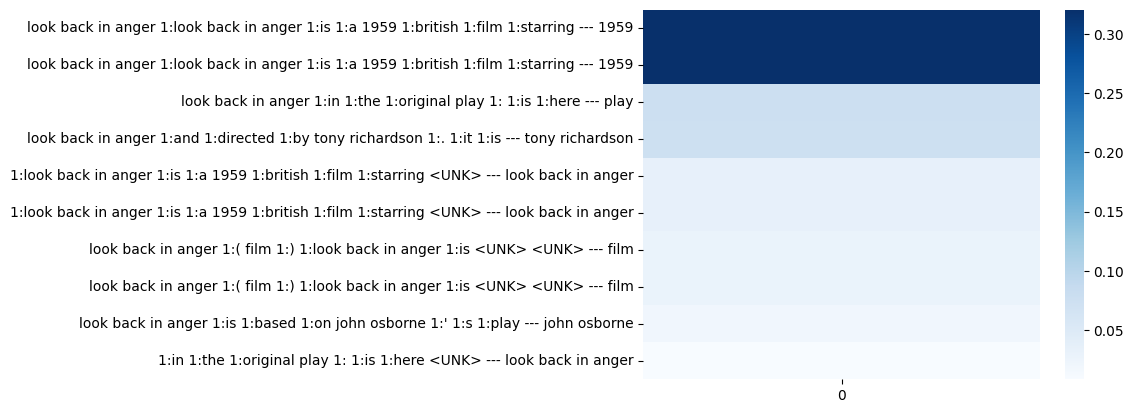

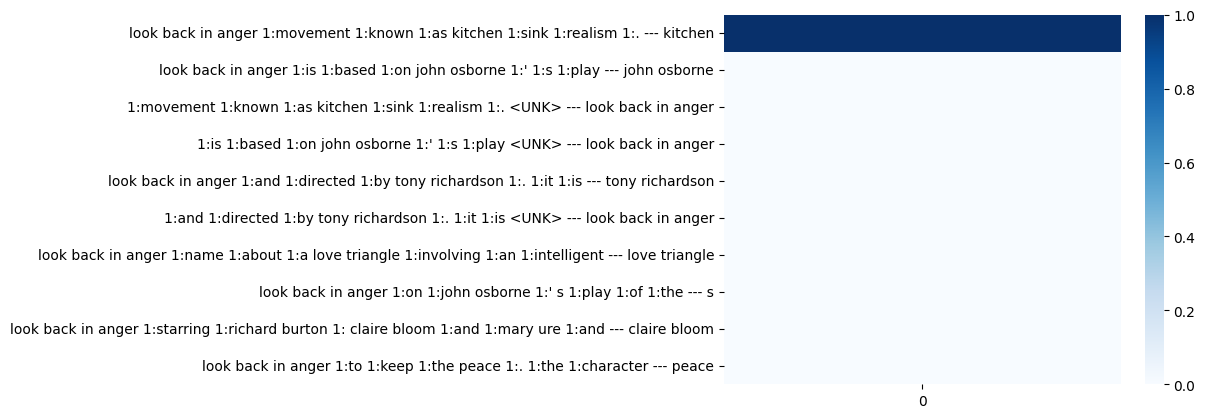

Predicted answer: 1959
Correct answer: 1959


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ejemplos interesantes: 8622, 5072
EXAMPLE_ID = 8622
N_KEYS_TO_PLOT = 10

print('Número de ejemplos en test:', len(test_dataset))

def predict_example(example):
    question, q_length, key, key_num_length, key_word_length, value, candidate, cand_length, answer = pad_batch([example])

    question, q_length, key = question.to(device), q_length.to(device), key.to(device)
    key_num_length, key_word_length, value = key_num_length.to(device), key_word_length.to(device), value.to(device)
    candidate, cand_length, answer = candidate.to(device), cand_length.to(device), answer.to(device)
    pred_index = model.predict(question, q_length, key, key_num_length,
                            key_word_length, value, candidate, cand_length)

    return pred_index

def visualize_example(example_id):
  example = test_dataset[example_id]

  pred_index = predict_example(example)
  question, q_length, key, key_num_length, key_word_length, value, candidate, cand_length, answer = example
  candidate = candidate.to(device)

  print('Q:', ids_to_txt(question[1:]))
  for i in range(len(model.attentions)):
      attention = model.attentions[i][0][0].cpu().detach()
      max_values_indices = attention.argsort()[-N_KEYS_TO_PLOT:].flip(0)
      labels = []
      for key_i in max_values_indices:
          labels.append('{} --- {}'.format(ids_to_txt(key[key_i]), ids_to_txt([value[key_i]])))
      sns.heatmap(attention[max_values_indices].unsqueeze(1), cmap='Blues', yticklabels=labels)
      plt.show()

  print('Predicted answer:', ids_to_txt([candidate[pred_index]]))
  print('Correct answer:', ids_to_txt([candidate[answer]]))

visualize_example(EXAMPLE_ID)

# Actividades

Elija **tres** de las siguientes actividades y responda. Solo se considerarán en la nota las **dos** con mejor puntaje.

Si responde más de tres preguntas solo se corregirán tres (considerando dentro de la nota solo las dos mejores).

Todas las actividades son respecto al modelo Key-Value Memory Network


## Actividad 1


Indique una forma en que cree que podría obtener/generar mejores embeddings para cada entrada de la KB (actualmente se genera creando un embedding aprendible para cada token y sumándolos).


In [41]:
R = """
Una forma clara de mejorar los embeddings de cada entrada de la KB es usar un **encoder contextual** (por ejemplo, BERT en español/inglés según el dataset) en vez de solo sumar embeddings de tokens.

¿Por qué podría mejorar?
1. **Contexto**: la suma de embeddings trata cada palabra casi de forma independiente. Un encoder contextual entiende mejor frases como "directed by" vs "acted in".
2. **Orden y sintaxis**: sumar tokens pierde mucha información de orden. Un encoder mantiene estructura de la oración.
3. **Desambiguación**: palabras ambiguas se representan distinto según contexto.

Propuesta práctica (simple):
- Para cada key de la KB, pasar el texto por un encoder preentrenado.
- Tomar el embedding de [CLS] (o promedio de tokens) como representación de esa key.
- Opcional: hacer fine-tuning ligero del encoder con QA del dominio.

Trade-off importante:
- Mejora calidad semántica, pero cuesta más memoria/tiempo de cómputo.
- Una solución intermedia para producción es **precalcular** embeddings offline y guardarlos.
"""

## Actividad 2

A continuación se muestran algunos casos hipotéticos en que se agregan entradas a la KB después de haber entrenado el modelo. En cada caso, indique si el modelo sería capaz de responder a preguntas relacionadas con estas nuevas entradas, sin reentrenar ni hacer fine-tuning. Fundamente su respuesta.

  1. Añadir nuevas entradas con entidades distintas a las que el modelo vio durante su entrenamiento



In [42]:
R = '''
**Caso 1: Añadir nuevas entradas con entidades nuevas (no vistas en entrenamiento)**

En general, el modelo tendrá **muchas dificultades** para responder bien sin reentrenar.

Fundamento:
1. Si las entidades nuevas no están en el vocabulario, se mapearán a `<NULL>` o `<UNK>`, perdiendo identidad semántica.
2. Aunque existan como token, el embedding no fue entrenado para esa entidad en ese contexto.
3. El mecanismo de atención puede recuperar una key, pero si la representación de tokens nuevos es pobre, la selección final de candidato también será pobre.

Conclusión:
- **No es confiable** esperar buen rendimiento con entidades totalmente nuevas sin fine-tuning o sin estrategia de OOV robusta.
'''

  2. Añadir nuevas entradas agregando nueva información sobre películas que ya están en la KB. Esta nueva información menciona solamente entidades que ya estaban en la KB y el modelo vio durante su entrenamiento.    

In [43]:
R = '''
**Caso 2: Nueva información sobre películas existentes, usando entidades ya vistas**

Aquí sí es **mucho más probable** que el modelo pueda responder sin reentrenar.

Fundamento:
1. Los tokens ya fueron vistos, por lo que sus embeddings son útiles.
2. Si el preprocesamiento genera keys/values compatibles con el formato del entrenamiento, la atención puede usar esas nuevas entradas.
3. El modelo ya aprendió el "patrón" de consulta (pregunta -> búsqueda en KB -> selección de candidato).

Limitación:
- Si la nueva información exige una forma de razonamiento muy distinta a la vista en entrenamiento, el desempeño puede caer.

Conclusión:
- **Sí, en general puede funcionar**, siempre que el formato de datos y el tipo de pregunta sean consistentes con el entrenamiento.
'''

## Actividad 3

Suponga que tiene ahora una base de datos de tuplas con la forma (sujeto, relación, objeto), por ejemplo (empanada, comida_típica_de, Chile),  y tiene que construir una base de conocimiento estilo key-value.  Indique qué utilizaría como keys y qué como values.
    

In [44]:
R = '''
Una forma simple y efectiva de construir la KB estilo key-value con tuplas (sujeto, relación, objeto) es:

- **Key**: (sujeto, relación)
- **Value**: objeto

Ejemplo:
- Tupla: (empanada, comida_típica_de, Chile)
- Key: [empanada, comida_típica_de]
- Value: [Chile]

Ventaja:
- Es directa para preguntas del tipo: "¿de qué país es típica la empanada?"

Mejora recomendada:
- Guardar también la tupla inversa para preguntas en dirección contraria.
- Tupla inversa: (Chile, tiene_comida_típica, empanada)
'''

Usando solamente la entrada (empanada, comida_típica_de, Chile) y **considerando la forma de definir keys y values que propuso en la pregunta anterior**, ¿cree usted que el modelo podría contestar las siguientes dos preguntas? Explique por qué cree que sí o que no, y en caso de que no se pueda indique qué podría hacer (a nivel de datos o de modelo) para que sí pueda responder ambas preguntas (**Hint:** puede crear nuevas tuplas a partir de las ya existentes):
  1. ¿De qué país es la empanada una comida típica?


In [45]:
R = '''
Para la pregunta 1 (**¿De qué país es la empanada una comida típica?**),
con la definición propuesta antes (key=(sujeto, relación), value=objeto):

- Key: (empanada, comida_típica_de)
- Value: Chile

Entonces **sí podría responder** esta pregunta, porque coincide con la dirección de la relación almacenada.

Por qué:
1. La pregunta contiene sujeto (empanada) y relación (comida_típica_de).
2. El modelo puede atender esa key y recuperar el value (Chile).
'''

  2. ¿Cuál es una comida típica de Chile?



In [46]:
R = '''
Para la pregunta 2 (**¿Cuál es una comida típica de Chile?**):

Con solo la tupla original (empanada, comida_típica_de, Chile) y key=(sujeto, relación), value=objeto,
**no queda natural responder**, porque ahora la consulta va en sentido inverso (desde Chile hacia comida).

Cómo habilitar ambas preguntas:
1. Crear una tupla inversa a nivel de datos:
   - (Chile, tiene_comida_típica, empanada)
2. Construir su entrada key-value:
   - Key: (Chile, tiene_comida_típica)
   - Value: empanada

Con esa ampliación, el modelo sí puede responder en ambas direcciones.
'''

## Actividad 4

A continuación hay un ejemplo (pregunta) inventado que no está en el dataset (en ningún split). Haga el preprocesamiento necesario a este ejemplo en la celda que se indica más adelante. Asegúrese de que corra el código de la celda siguiente, que debería mostrar la visualización del modelo al pasarle este ejemplo y contestar correctamente.

Para el preprocesamiento puede basarse en el código de las secciones "Preprocesar datos" y "Modelo y dataloaders", y utilizar las funciones que están ahí.

IMPORTANTE: Para que este código funcione debe haber corrido previamente todas las celdas de este notebook (menos la del entrenamiento)

In [47]:
token_dict = {token: i for i, token in enumerate(dict_txt)}
new_question_txt = '<NULL> who directed doomsday ? 1:who 1:directed 1:doomsday 1: ?'
new_question = [token_dict[token] for token in new_question_txt.split()]
new_answer = [token_dict['neil marshall']]
new_q_orig = [new_question]
new_a_orig = [new_answer]

In [48]:
# Preprocesamos el ejemplo nuevo usando las mismas funciones del pipeline original.
# Objetivo: generar exactamente estas variables:
# new_q, new_q_word_lengths, new_key, new_key_num_lengths, new_key_word_lengths,
# new_value, new_cand, new_cand_lengths, new_a

# 1) Generar candidatos de KB y estructuras base
new_q, new_key, new_value, new_cand, new_a = gen_candidates(new_q_orig, new_a_orig)

# 2) Aplicar padding a los keys tal como se hizo en entrenamiento
new_key = pad_all_keys(new_key)

# 3) Calcular largos necesarios para padding/máscaras en el modelo
new_q_word_lengths, new_key_num_lengths, new_key_word_lengths, new_cand_lengths = get_data_lengths(
    new_q, new_key, new_cand
)

# 4) Chequeo rápido (opcional) para validar que hay al menos un ejemplo procesado
print('Ejemplos procesados:', len(new_q))
if len(new_q) == 0:
    print('Advertencia: no se encontraron candidatos que contengan la respuesta en la KB filtrada.')
else:
    print('Preprocesamiento OK. Listo para visualizar con visualize_example(0).')

100%|██████████| 1/1 [00:00<00:00, 455.36it/s]

Ejemplos procesados: 1
Preprocesamiento OK. Listo para visualizar con visualize_example(0).


Q: who directed doomsday ? 1:who 1:directed 1:doomsday 1: ?


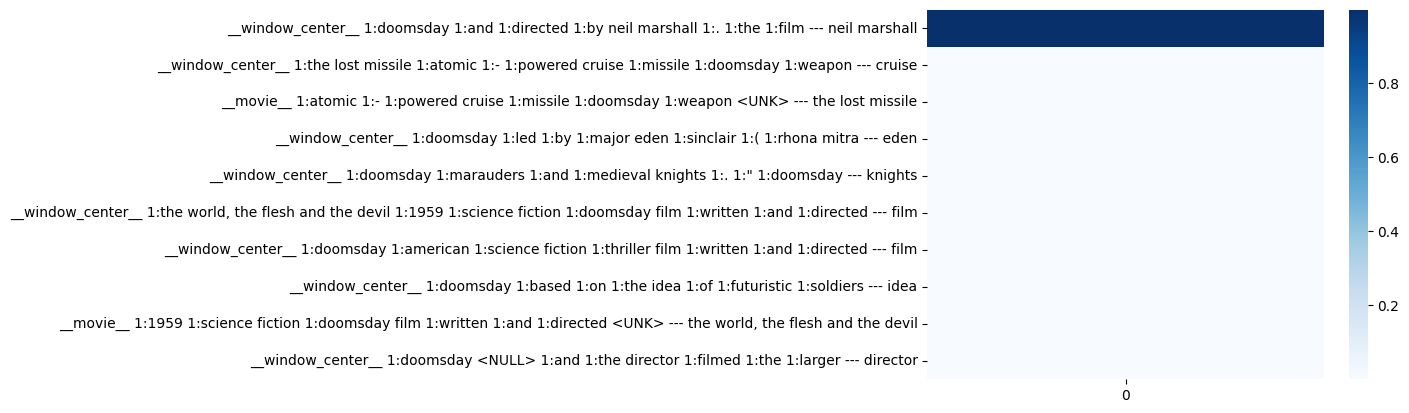

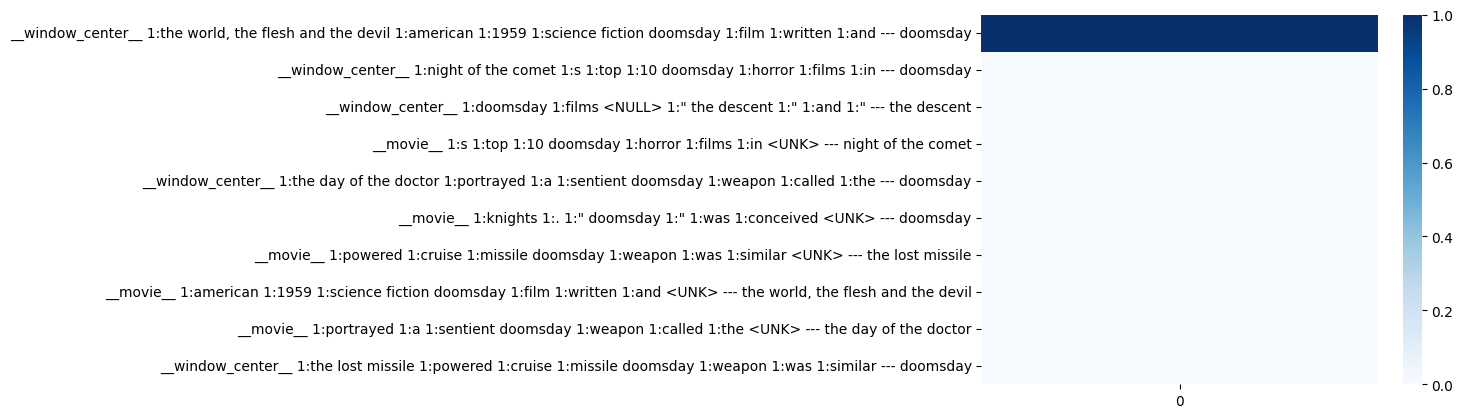

Predicted answer: neil marshall
Correct answer: neil marshall


In [49]:
test_dataset = list(zip(
    # ESTAS SON LAS VARIABLES QUE DEBE GENERAR SU CÓDIGO
    new_q, new_q_word_lengths, new_key, new_key_num_lengths, new_key_word_lengths,
    new_value, new_cand, new_cand_lengths, new_a
))
visualize_example(0)